# Finite Difference Method for Quantum Mechanics

## Imports


In [26]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sparse
import scipy.sparse.linalg as linalg
from scipy.sparse.linalg import eigsh
import time


## 2nd Order Finite Difference Functions


In [27]:
def spatial(x_left, x_right, N):
    return np.linspace(x_left, x_right, N+2)[1:-1]

def proj(f, grid):
    return np.array([f(point) for point in grid], dtype=complex)

## 2nd and 4th Order Finite Difference Functions


In [28]:
def _diag(A, C, grid):
    x = grid
    del_x = x[1] - x[0]
    N = len(x)
    
    rows = np.arange(N)
    cols = rows
    
    a = proj(A, x)
    c = proj(C, x)
    data = c - (2.0 * a) / (del_x**2)
    
    return rows, cols, data

def _upper(A, B, grid):
    x = grid[:-1]  # all except last point
    del_x = grid[1] - grid[0]
    N = len(grid)
    
    rows = np.arange(N-1)
    cols = rows + 1
    
    a = proj(A, x)
    b = proj(B, x)
    data = (a / (del_x**2)) + (b / (2.0 * del_x))
    
    return rows, cols, data

def _lower(A, B, grid):
    x = grid[1:]  # all except first point
    del_x = grid[1] - grid[0]
    N = len(grid)
    
    rows = np.arange(1, N)
    cols = rows - 1
    
    a = proj(A, x)
    b = proj(B, x)
    data = (a / (del_x**2)) - (b / (2.0 * del_x))
    
    return rows, cols, data

def sparseMatrixMaker(A, B, C, grid):
    rD, cD, dD = _diag(A, C, grid)
    rU, cU, dU = _upper(A, B, grid)
    rL, cL, dL = _lower(A, B, grid)

    rows = np.concatenate([rD, rU, rL])
    cols = np.concatenate([cD, cU, cL])
    data = np.concatenate([dD, dU, dL])

    N = len(grid)
    return sparse.coo_matrix((data, (rows, cols)), shape=(N, N))



In [29]:
def _diag_4th(A, B, C, grid):
    x = grid  # all points
    h = grid[1] - grid[0]
    N = len(grid)
    
    rows = np.arange(N)
    cols = rows
    
    a = proj(A, x)
    b = proj(B, x)
    c = proj(C, x)
    data = c - (30.0 * a) / (12 * h**2)
    
    return rows, cols, data

def _upper_4th(A, B, grid):
    x = grid[:-1]  # all except last point
    h = grid[1] - grid[0]
    N = len(grid)
    
    rows = np.arange(N-1)
    cols = rows + 1
    
    a = proj(A, x)
    b = proj(B, x)
    data = (16.0 * a) / (12 * h**2) + (8.0 * b) / (12 * h)
    
    return rows, cols, data

def _lower_4th(A, B, grid):
    x = grid[1:]  # all except first point
    h = grid[1] - grid[0]
    N = len(grid)
    
    rows = np.arange(1, N)
    cols = rows - 1
    
    a = proj(A, x)
    b = proj(B, x)
    data = (16.0 * a) / (12 * h**2) - (8.0 * b) / (12 * h)
    
    return rows, cols, data

def _upper2_4th(A, B, grid):
    x = grid[:-2]  # all except last two points
    h = grid[1] - grid[0]
    N = len(grid)
    
    rows = np.arange(N-2)
    cols = rows + 2
    
    a = proj(A, x)
    b = proj(B, x)
    data = (-1.0 * a) / (12 * h**2) + (1.0 * b) / (12 * h)
    
    return rows, cols, data

def _lower2_4th(A, B, grid):
    x = grid[2:]  # all except first two points
    h = grid[1] - grid[0]
    N = len(grid)
    
    rows = np.arange(2, N)
    cols = rows - 2
    
    a = proj(A, x)
    b = proj(B, x)
    data = (-1.0 * a) / (12 * h**2) - (1.0 * b) / (12 * h)
    
    return rows, cols, data

def _triplets_4th_Au_xx_plus_Bu_x_plus_Cu(A, B, C, grid):
    rD, cD, dD = _diag_4th(A, B, C, grid)
    rU, cU, dU = _upper_4th(A, B, grid)
    rL, cL, dL = _lower_4th(A, B, grid)
    rU2, cU2, dU2 = _upper2_4th(A, B, grid)
    rL2, cL2, dL2 = _lower2_4th(A, B, grid)

    rows = np.concatenate([rD, rU, rL, rU2, rL2])
    cols = np.concatenate([cD, cU, cL, cU2, cL2])
    data = np.concatenate([dD, dU, dL, dU2, dL2])

    return rows, cols, data

def sparse_Matrix_Maker4(A, B, C, grid):
    r, c, d = _triplets_4th_Au_xx_plus_Bu_x_plus_Cu(A, B, C, grid)
    N = len(grid)
    return sparse.coo_matrix((d, (r, c)), shape=(N, N))

## Matrix Verification Test


In [30]:
def hamiltonian(V, x_left, x_right, N):
    N = int(N)
    grid = spatial(x_left, x_right, N)
    
    def A(x): return -0.5  # kinetic energy coefficient
    def B(x): return 0.0
    def C(x): return V(x)  # potential energy
    
    return sparseMatrixMaker(A, B, C, grid).tocsr()

def hamiltonian_4th(V, x_left, x_right, N):
    N = int(N)
    grid = spatial(x_left, x_right, N)
    
    def A(x): return -0.5
    def B(x): return 0.0
    def C(x): return V(x)
    
    return sparse_Matrix_Maker4(A, B, C, grid).tocsr()

## Timing Comparison: 2nd vs 4th Order Methods


## Convergence Analysis: 4th Order Method


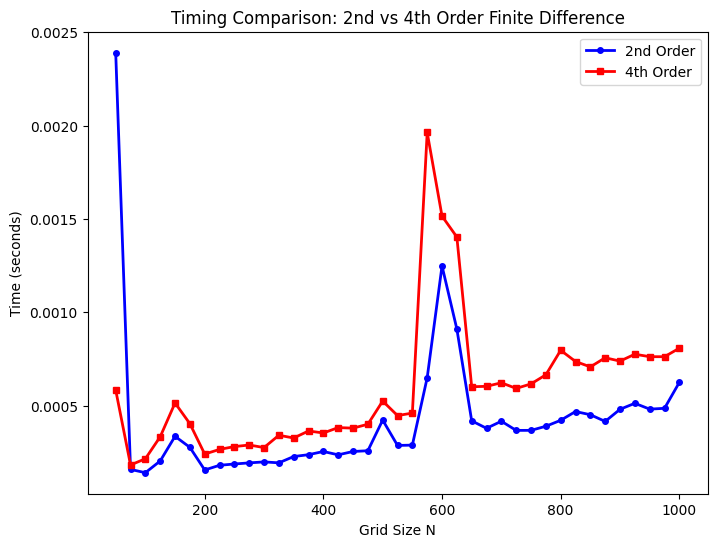

In [31]:
def timing_hamiltonian_2nd(N):
    def V(x): return 0.5 * x**2
    x_left, x_right = -5.0, 5.0
    start = time.time()
    H = hamiltonian(V, x_left, x_right, N)
    end = time.time()
    return end - start

def timing_hamiltonian_4th(N):
    def V(x): return 0.5 * x**2
    x_left, x_right = -5.0, 5.0
    start = time.time()
    H = hamiltonian_4th(V, x_left, x_right, N)
    end = time.time()
    return end - start

N_values = np.arange(50, 1001, 25)
timing_2nd = []
timing_4th = []

for N in N_values:
    timing_2nd.append(timing_hamiltonian_2nd(N))
    timing_4th.append(timing_hamiltonian_4th(N))

plt.figure(figsize=(8, 6))
plt.plot(N_values, timing_2nd, 'b-o', label='2nd Order', linewidth=2, markersize=4)
plt.plot(N_values, timing_4th, 'r-s', label='4th Order', linewidth=2, markersize=4)
plt.xlabel('Grid Size N')
plt.ylabel('Time (seconds)')
plt.title('Timing Comparison: 2nd vs 4th Order Finite Difference')
plt.legend()
plt.show()



## Convergence Analysis: 4th Order Method


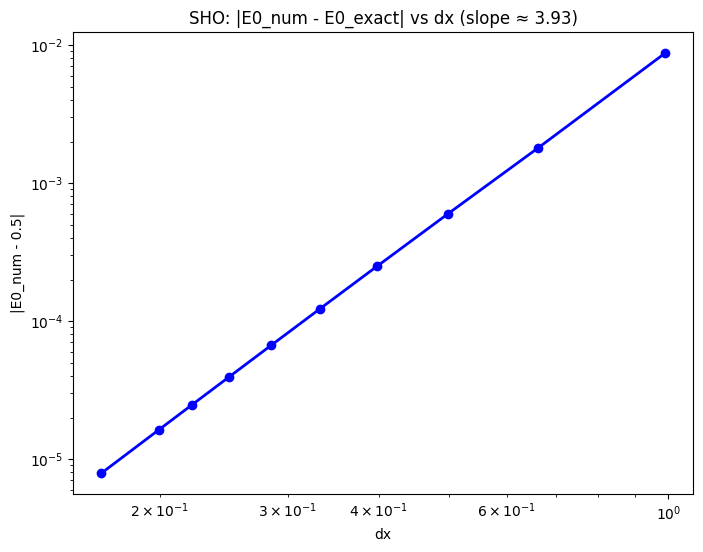

In [32]:
def E_exact_sho(n, omega=1.0): 
    return n + 0.5

target_n = 0
E0_exact = E_exact_sho(target_n)

x_inf = 100.0 
x_left, x_right = -x_inf, x_inf

def V(x): 
    return 0.5 * x**2

N_list = [201, 301, 401, 501, 601, 701, 801, 901, 1001, 1201]
errs, dxs = [], []

for N_test in N_list:
    Ht = hamiltonian_4th(V, x_left, x_right, N_test)
    Et, _ = eigsh(Ht, k=1, which='SM', tol=1e-10, maxiter=2000)
    Et = np.min(Et)
    grid_t = spatial(x_left, x_right, N_test)
    dx = grid_t[1] - grid_t[0]
    error = abs(Et - E0_exact)
    
    dxs.append(dx)
    errs.append(error)

plt.figure(figsize=(8, 6))
plt.loglog(dxs, errs, 'bo-', linewidth=2, markersize=6)

slope = (np.log(errs[-1]) - np.log(errs[0])) / (np.log(dxs[-1]) - np.log(dxs[0]))
plt.title(f"SHO: |E0_num - E0_exact| vs dx (slope ≈ {slope:.2f})")
plt.xlabel("dx")
plt.ylabel("|E0_num - 0.5|")
plt.show()


## Matrix Verification Test


In [33]:
x_left, x_right = 1.0, 2.0
N = 4

def A(x): return 2*x
def B(x): return x**2  
def C(x): return 1.0

grid = spatial(x_left, x_right, N)
print(f"Grid points: {grid}")
print(f"Grid spacing Δ = {grid[1] - grid[0]:.3f}")
print()

a_vals = proj(A, grid)
b_vals = proj(B, grid) 
c_vals = proj(C, grid)

print(f"A(x) values: {a_vals}")
print(f"B(x) values: {b_vals}")
print(f"C(x) values: {c_vals}")
print()


Grid points: [1.2 1.4 1.6 1.8]
Grid spacing Δ = 0.200

A(x) values: [2.4+0.j 2.8+0.j 3.2+0.j 3.6+0.j]
B(x) values: [1.44+0.j 1.96+0.j 2.56+0.j 3.24+0.j]
C(x) values: [1.+0.j 1.+0.j 1.+0.j 1.+0.j]



In [34]:
actual_2nd = sparseMatrixMaker(A, B, C, grid).toarray()
print("Actual 2nd order matrix:")
print(actual_2nd)
print()


Actual 2nd order matrix:
[[-119. +0.j   63.6+0.j    0. +0.j    0. +0.j]
 [  65.1+0.j -139. +0.j   74.9+0.j    0. +0.j]
 [   0. +0.j   73.6+0.j -159. +0.j   86.4+0.j]
 [   0. +0.j    0. +0.j   81.9+0.j -179. +0.j]]



In [35]:
actual_4th = sparse_Matrix_Maker4(A, B, C, grid).toarray()
print("Actual 4th order matrix:")
print(actual_4th)
print()


Actual 4th order matrix:
[[-149.        +0.j   84.8       +0.j   -4.4       +0.j    0.        +0.j]
 [  86.8       +0.j -174.        +0.j   99.86666667+0.j   -5.01666667+0.j]
 [  -7.73333333+0.j   98.13333333+0.j -199.        +0.j  115.2       +0.j]
 [   0.        +0.j   -8.85      +0.j  109.2       +0.j -224.        +0.j]]

